# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [I Komang Galih Agustan]
- **Email:** [galihagustan2@gmail.com]
- **ID Dicoding:** [Galihagustansukidayo]

## Menentukan Pertanyaan Bisnis

- Produk dan kategori produk apa yang menghasilkan total pendapatan tertinggi selama tahun 2017 hingga pertengahan 2018?
- produk dan kategori produk apa yang paling sering dibeli di Sao Paulo pada periode 2017-2018?
- Bagaimana tren bulanan volume transaksi dari januari 2017 hingga agustus 2018 dan wilayah mana yang memberikan kontribusi pendapatan lebih dari setengah terhadap total ppenjualan?

## Import Semua Packages/Library yang Digunakan

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip freeze > requirements.txt

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Wrangling

### Gathering Data

In [48]:
df_list_customers = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_customers_dataset.csv")
df_list_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [49]:
df_list_geolocation = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_geolocation_dataset.csv")
df_list_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [50]:
df_list_orderitem = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_order_items_dataset.csv")
df_list_orderitem.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [51]:
df_list_payments = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_order_payments_dataset.csv")
df_list_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [52]:
df_list_order_reviews = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_order_reviews_dataset.csv")
df_list_order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [53]:
df_list_orders = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_orders_dataset.csv")
df_list_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [54]:
df_list_products = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_products_dataset.csv")
df_list_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [55]:
df_list_sellers = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_sellers_dataset.csv")
df_list_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [56]:
df_list_product_category = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/product_category_name_translation.csv")
df_list_product_category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Merging

In [57]:
# orders dengan order items
df_orders_items = df_list_orders.merge(df_list_orderitem, on='order_id', how='left')

# info pembayaran
df_orders_items = df_orders_items.merge(df_list_payments, on='order_id', how='left')

# info pelanggan
df_orders_items = df_orders_items.merge(df_list_customers, on='customer_id', how='left')

# info produk
df_orders_items = df_orders_items.merge(df_list_products, on='product_id', how='left')

# terjemahan kategori produk
df_orders_items = df_orders_items.merge(df_list_product_category, on='product_category_name', how='left')

# info penjual
df_orders_items = df_orders_items.merge(df_list_sellers, on='seller_id', how='left')


In [58]:
df_orders_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP


In [59]:
df_orders_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  object 
 1   customer_id                    118434 non-null  object 
 2   order_status                   118434 non-null  object 
 3   order_purchase_timestamp       118434 non-null  object 
 4   order_approved_at              118258 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  118434 non-null  object 
 8   order_item_id                  117604 non-null  float64
 9   product_id                     117604 non-null  object 
 10  seller_id                      117604 non-null  object 
 11  shipping_limit_date            117604 non-null  object 
 12  price                         

In [60]:
df_orders_items.describe()

,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,customer_zip_code_prefix,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix
count,117604.000000,117604.000000,117604.000000,118431.000000,118431.000000,118431.000000,118434.000000,115906.000000,115906.000000,115906.000000,117584.000000,117584.000000,117584.00000,117584.000000,117604.000000
mean,1.195920,120.822849,20.045551,1.094207,2.937398,172.849395,35034.264392,48.767208,786.957302,2.207849,2114.281067,30.256872,16.63029,23.068394,24442.886483
std,0.697721,184.477367,15.861351,0.728290,2.774164,268.259831,29819.290218,10.035162,653.029009,1.719519,3788.754048,16.190874,13.45878,11.748372,27573.802989
min,1.000000,0.850000,0.000000,1.000000,0.000000,0.000000,1003.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.00000,6.000000,1001.000000
25%,1.000000,39.900000,13.080000,1.000000,1.000000,60.860000,11310.000000,42.000000,347.000000,1.000000,300.000000,18.000000,8.00000,15.000000,6429.000000
50%,1.000000,74.900000,16.290000,1.000000,2.000000,108.200000,24240.000000,52.000000,601.000000,1.000000,700.000000,25.000000,13.00000,20.000000,13660.000000
75%,1.000000,134.900000,21.190000,1.000000,4.000000,189.245000,58464.500000,57.000000,985.000000,3.000000,1800.000000,38.000000,20.00000,30.000000,28035.000000
max,21.000000,6735.000000,409.680000,29.000000,24.000000,13664.080000,99990.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.00000,118.000000,99730.000000


**Insight:**
- order_item_id dengan rata rata 1.19 dan maximum 21 berarti sebagian besar order itu dikisaran 1 item tapi ada pesanan sangat banyak hingga 21 item. kemungkinan ada pelanggan premium
- pada kolom price diketahui bahwa ada produk yang sangat murah yakni 0.85 dan produk sangat mahal (6735). kategori produk sangat beragam
- payment_installments rata rata 3 kali cicilan dan max 24 kali yang artinya banyak pelanggan masih mencicil untuk transaksi
- payment_value memiliki rata rata 172 dan max 13.664. sebagian besar transaksinya kecil hingga menengah tetapi adapun transaksi yang sangat besar
- produk sangat beragam, bisa dilihat dari product weight dengan median 700 g hingga maximum 400 g dengan rata rata 2000g/2kg.

### Assessing Data

cek missing value


In [61]:
df_orders_items.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,176
order_delivered_carrier_date,2074
order_delivered_customer_date,3397
order_estimated_delivery_date,0
order_item_id,830
product_id,830


cek nilai unik

In [62]:
for col in df_orders_items.columns:
    print(f"Kolom: {col}")
    print(df_orders_items[col].unique()[:10])
    print("Jumlah unik:", df_orders_items[col].nunique())
    print("-"*50)


Kolom: order_id
['e481f51cbdc54678b7cc49136f2d6af7' '53cdb2fc8bc7dce0b6741e2150273451'
 '47770eb9100c2d0c44946d9cf07ec65d' '949d5b44dbf5de918fe9c16f97b45f8a'
 'ad21c59c0840e6cb83a9ceb5573f8159' 'a4591c265e18cb1dcee52889e2d8acc3'
 '136cce7faa42fdb2cefd53fdc79a6098' '6514b8ad8028c9f2cc2374ded245783f'
 '76c6e866289321a7c93b82b54852dc33' 'e69bfb5eb88e0ed6a785585b27e16dbf']
Jumlah unik: 99441
--------------------------------------------------
Kolom: customer_id
['9ef432eb6251297304e76186b10a928d' 'b0830fb4747a6c6d20dea0b8c802d7ef'
 '41ce2a54c0b03bf3443c3d931a367089' 'f88197465ea7920adcdbec7375364d82'
 '8ab97904e6daea8866dbdbc4fb7aad2c' '503740e9ca751ccdda7ba28e9ab8f608'
 'ed0271e0b7da060a393796590e7b737a' '9bdf08b4b3b52b5526ff42d37d47f222'
 'f54a9f0e6b351c431402b8461ea51999' '31ad1d1b63eb9962463f764d4e6e0c9d']
Jumlah unik: 99441
--------------------------------------------------
Kolom: order_status
['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved'

invalid value


In [63]:
df_orders_items[df_orders_items['payment_value']<=0]
df_orders_items[df_orders_items['freight_value']<0]
df_orders_items[df_orders_items['product_weight_g']<=0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
6055,06afc1144eb9f51ef2aa90ec9223c7f4,e8be078dee76002545a9c5f10b7d7c4e,delivered,2018-08-15 17:13:07,2018-08-15 17:25:20,2018-08-16 14:44:00,2018-08-24 22:54:42,2018-09-20 00:00:00,1.0,e673e90efa65a5409ff4196c038bb5af,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
6056,06afc1144eb9f51ef2aa90ec9223c7f4,e8be078dee76002545a9c5f10b7d7c4e,delivered,2018-08-15 17:13:07,2018-08-15 17:25:20,2018-08-16 14:44:00,2018-08-24 22:54:42,2018-09-20 00:00:00,2.0,e673e90efa65a5409ff4196c038bb5af,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
15179,4abc7b5330425bcf9c2f7f48151a88c0,d1568f1104d2015dc70bdf7d9ab88dd2,delivered,2018-07-31 21:05:49,2018-07-31 21:40:18,2018-08-01 16:00:00,2018-08-07 23:56:48,2018-08-17 00:00:00,1.0,8038040ee2a71048d4bdbbdc985b69ab,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
46797,200b121c28e10ef638131a7c76753327,26bcca10e5c9679c306d8333bf527929,delivered,2018-08-04 15:55:59,2018-08-04 16:10:16,2018-08-08 14:35:00,2018-08-23 18:21:59,2018-08-30 00:00:00,1.0,81781c0fed9fe1ad6e8c81fca1e1cb08,...,529.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
77602,476b812a7e4fc972646eb390517bddcb,18a1176652a9344ba489fa4ccaa3c20f,delivered,2018-08-18 11:09:12,2018-08-18 11:30:54,2018-08-21 12:07:00,2018-08-30 16:56:44,2018-09-12 00:00:00,1.0,e673e90efa65a5409ff4196c038bb5af,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
108918,b489f7ae130ba3fd26b0a20f8cc81c61,99411e9599f8b7a90f2a362b874b66ca,delivered,2018-08-18 20:37:22,2018-08-18 20:49:57,2018-08-20 14:20:00,2018-08-27 14:52:02,2018-09-04 00:00:00,1.0,e673e90efa65a5409ff4196c038bb5af,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
116773,06d9e69034388abf6da64378e10737b8,afef0047e43944e8c6630ec0d0f7de2e,delivered,2018-07-30 10:42:40,2018-07-31 09:10:11,2018-07-31 14:24:00,2018-08-09 22:18:29,2018-09-10 00:00:00,1.0,36ba42dd187055e1fbe943b2d11430ca,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
116774,06d9e69034388abf6da64378e10737b8,afef0047e43944e8c6630ec0d0f7de2e,delivered,2018-07-30 10:42:40,2018-07-31 09:10:11,2018-07-31 14:24:00,2018-08-09 22:18:29,2018-09-10 00:00:00,2.0,36ba42dd187055e1fbe943b2d11430ca,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP


In [64]:
invalid_data = df_orders_items[
    (df_orders_items['order_delivered_customer_date'] < df_orders_items['order_purchase_timestamp'])
]
invalid_data2 = df_orders_items[
    (df_orders_items['order_delivered_carrier_date'] < df_orders_items['order_approved_at'])
]
invalid_data3 = df_orders_items[
    (df_orders_items['order_delivered_customer_date'] < df_orders_items['order_delivered_carrier_date'])
]

print("Panjang invalid_data 1:", len(invalid_data))
print("Panjang invalid_data 2:", len(invalid_data2))
print("Panjang invalid_data 3:", len(invalid_data3))


Panjang invalid_data 1: 0
Panjang invalid_data 2: 1600
Panjang invalid_data 3: 59


In [65]:
invalid_price = df_orders_items[df_orders_items['price'] <= 0]
invalid_freight = df_orders_items[df_orders_items['freight_value'] < 0]
invalid_payment = df_orders_items[df_orders_items['payment_value'] <= 0]

print(len(invalid_price), len(invalid_freight), len(invalid_payment))


0 0 9


cek value duplicated


In [66]:
df_orders_items.duplicated().sum()

np.int64(0)

In [67]:
df_orders_items.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object
order_item_id,float64
product_id,object


cek outlier

In [68]:
Q1 = df_orders_items['price'].quantile(0.25)
Q3 = df_orders_items['price'].quantile(0.75)
IQR = Q3 - Q1

# batas atas dan bawah
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# filter outlier
outliers = df_orders_items[(df_orders_items['price'] < lower_bound) | (df_orders_items['price'] > upper_bound)]
outliers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
20,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,delivered,2018-01-02 19:00:43,2018-01-02 19:09:04,2018-01-03 18:19:09,2018-01-20 01:38:59,2018-02-06 00:00:00,1.0,638bbb2a5e4f360b71f332ddfebfd672,...,143.0,2.0,20850.0,100.0,25.0,50.0,construction_tools_construction,8840.0,mogi das cruzes,SP
37,f70a0aff17df5a6cdd9a7196128bd354,456dc10730fbdba34615447ea195d643,delivered,2017-08-10 11:58:33,2017-08-12 02:45:24,2017-08-17 15:35:07,2017-08-18 14:28:02,2017-08-23 00:00:00,1.0,cafd558df4c3c9d1c338ba6930ea9a62,...,1009.0,1.0,16450.0,44.0,70.0,32.0,baby,13450.0,santa barbara d´oeste,SP
45,434d158e96bdd6972ad6e6d73ddcfd22,2a1dfb647f32f4390e7b857c67458536,delivered,2018-06-01 12:23:13,2018-06-05 03:35:15,2018-06-08 11:49:00,2018-06-18 21:32:52,2018-07-17 00:00:00,1.0,c7df652246ed7b3300aaf46960c141e4,...,1455.0,1.0,683.0,29.0,15.0,22.0,health_beauty,87303.0,campo mourao,PR
48,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21 00:00:00,1.0,be021417a6acb56b9b50d3fd2714baa8,...,664.0,6.0,14300.0,38.0,34.0,34.0,housewares,89165.0,rio do sul,SC
61,641fb0752bf5b5940c376b3a8bb9dc52,f5afca14dfa9dc64251cf2b45c54c363,delivered,2017-12-15 00:06:10,2017-12-15 00:14:55,2017-12-19 01:58:00,2018-01-03 15:09:32,2018-01-16 00:00:00,1.0,60184212dae4e6b0da32bf54271a8c4a,...,476.0,2.0,394.0,17.0,11.0,14.0,watches_gifts,14850.0,pradopolis,SP


cek outlier dengan visual

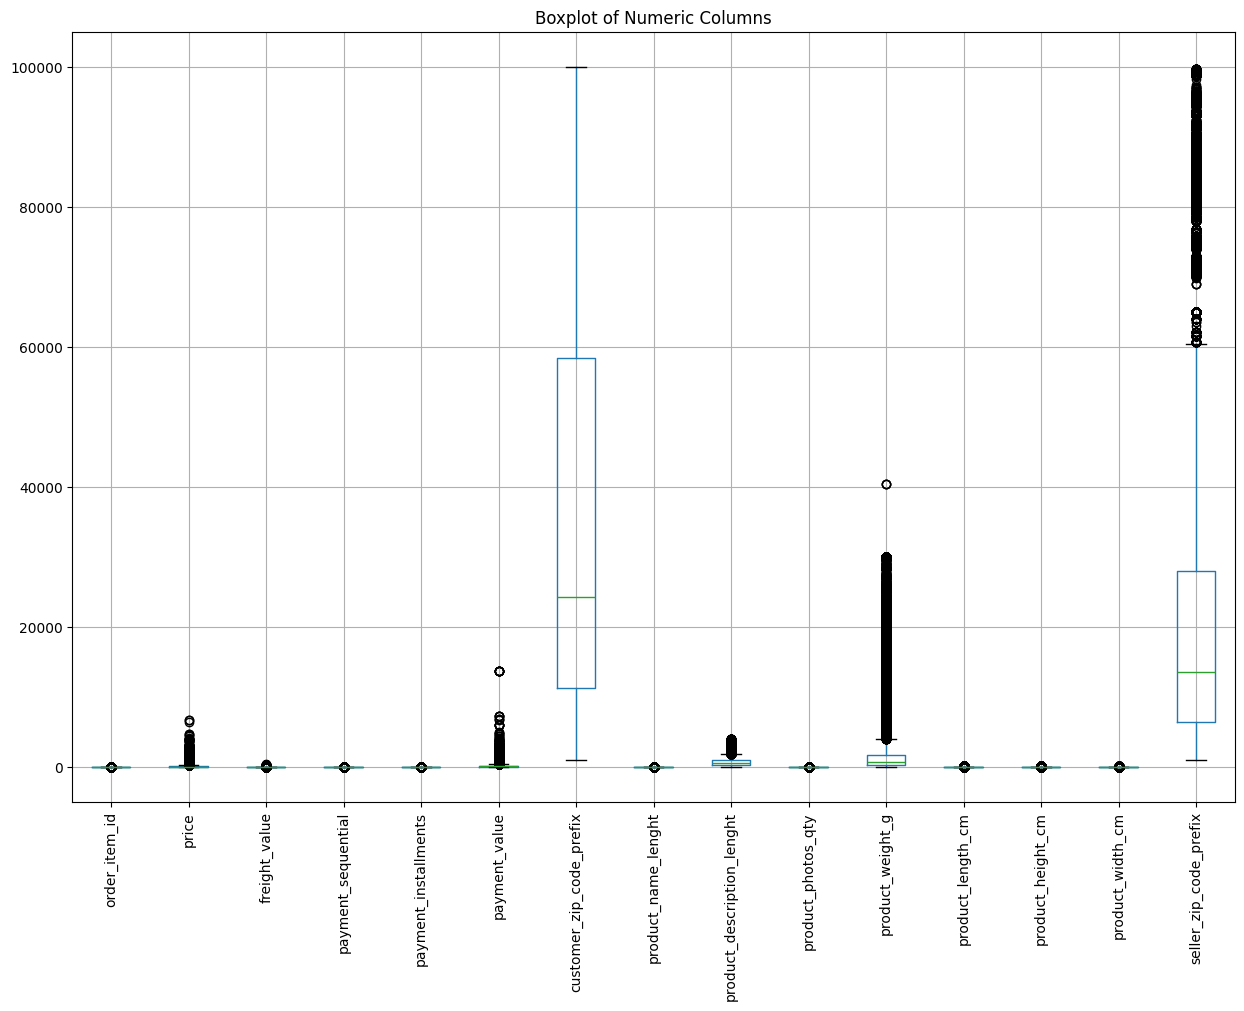

In [69]:
numeric_cols = df_orders_items.select_dtypes(include=[np.number]).columns
# boxplot
plt.figure(figsize=(15, 10))
df_orders_items[numeric_cols].boxplot()
plt.xticks(rotation=90)
plt.title('Boxplot of Numeric Columns')
plt.show()

In [70]:
df_orders_items['payment_type'].value_counts()

,count
payment_type,
credit_card,87286
boleto,23037
voucher,6407
debit_card,1698
not_defined,3


**Insight:**
- Masih terdapat missing values yang harus ditangani mulai dari dengan missing values yang relatif sedikit, contohnya kolom order_approved, relatif sedang seperti order_item_id, dan tinggi seperti product_category_name.
- Terdapat invalid value pada beberapa kolom, misalnya payment_value bernilai 0 padahal order delivered, freight_value bernilai 0 yang bisa jadi error atau promo free shipping, serta product_weight_g bernilai 0 yang jelas saja ini tidak valid. ini wajib ditangani pada tahap cleaning.
- pada kolom price, masih terdapat outlier yang wajib ditangani, outlier ini akan diisi oleh median value sebagai pengganti.
- ditemukan 1659 baris dengan urutan tidak logis (di segmen invalid data) ini akan dihapus di bagian cleaning data

### Cleaning Data

info penting sebelum cleaning. ada status order yakni created, approved shipped, canceled, dan delivered. maka yang bermasalah adalah yang sudah delivered tetapi tidak memiliki informasi item sehingga ini bisa berbahaya.

handle missing value

In [71]:
df_before = df_orders_items[df_orders_items['order_status']=='delivered'].copy()
# membuang baris
df_clean = df_before[df_before['order_item_id'].notna()]
df_clean = df_clean[df_clean['payment_type'].notna()]
print('Ukuran data awal:', df_before.shape[0])
print('Ukuran data setelah:', df_clean.shape[0])
df_clean.head()

Ukuran data awal: 115038
Ukuran data setelah: 115035


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP


menangani missing di product kategori dan yang satu lagi yang berbahasa inggris

In [72]:
df_clean['product_category_name'] = df_clean['product_category_name'].fillna('Unknown')
df_clean['product_category_name_english'] = df_clean['product_category_name_english'].fillna('Unknown')

# df_clean.isnull().sum()

menangani invalid value

In [73]:
invalid_data = df_orders_items[(df_orders_items['order_delivered_customer_date'] < df_orders_items['order_purchase_timestamp'])]
invalid_data2 = df_orders_items[(df_orders_items['order_delivered_carrier_date'] < df_orders_items['order_approved_at'])]
invalid_data3 = df_orders_items[(df_orders_items['order_delivered_customer_date'] < df_orders_items['order_delivered_carrier_date'])]

all_invalid_indices = pd.concat([invalid_data, invalid_data2, invalid_data3]).index

# Filter only the indices that exist in df_clean
existing_invalid_indices = df_clean.index.intersection(all_invalid_indices)

df_clean = df_clean.drop(index=existing_invalid_indices)

print('Ukuran data setelah:', df_clean.shape[0])

Ukuran data setelah: 113385


cek harga dan pembayaran

In [74]:
invalid_price = df_orders_items[df_orders_items['price'] <= 0]
invalid_freight = df_orders_items[df_orders_items['freight_value'] < 0]
invalid_payment = df_orders_items[df_orders_items['payment_value'] <= 0]
invalid_photo = df_clean[df_clean['product_photos_qty'] < 0]

all_invalid_data = pd.concat([invalid_price, invalid_freight, invalid_payment, invalid_photo]).index

# Filter only the indices that exist in df_clean
existing_invalid_data = df_clean.index.intersection(all_invalid_data)

df_clean = df_clean.drop(index=existing_invalid_data)

print('Ukuran data setelah:', df_clean.shape[0])

Ukuran data setelah: 113381


invalid installments & item id


In [75]:
invalid_installments = df_clean[df_clean['payment_installments'] < 0]
invalid_item_id = df_clean[df_clean['order_item_id'] < 0]

print(len(invalid_installments), len(invalid_item_id))

0 0


memastikan semua kolom tanggal bertipe datetime

In [76]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col])

# df_clean.info()


In [77]:
dup_rows = df_clean[df_clean.duplicated(subset=['order_id','order_item_id'], keep=False)]
dup_rows[['order_id','order_item_id','payment_sequential','payment_type','payment_value']].head(20)


,order_id,order_item_id,payment_sequential,payment_type,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,1.0,1.0,credit_card,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,1.0,3.0,voucher,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,1.0,2.0,voucher,18.59
11,e69bfb5eb88e0ed6a785585b27e16dbf,1.0,2.0,voucher,161.42
12,e69bfb5eb88e0ed6a785585b27e16dbf,1.0,1.0,credit_card,8.34
23,83018ec114eee8641c97e08f7b4e926f,1.0,2.0,voucher,62.15
24,83018ec114eee8641c97e08f7b4e926f,1.0,3.0,voucher,24.86
25,83018ec114eee8641c97e08f7b4e926f,1.0,1.0,credit_card,5.96
96,634e8f4c0f6744a626f77f39770ac6aa,1.0,2.0,voucher,227.20
97,634e8f4c0f6744a626f77f39770ac6aa,1.0,1.0,credit_card,7.08


**Insight:**
- Data lebih rapi, konsisten, dan siap untuk analisis lanjutan
- Tidak ada noise yyang bisa mengganggu visualisasi

## Exploratory Data Analysis (EDA)

### Pertanyaan 1: Produk dan kategori produk apa yang menghasilkan total pendapatan tertinggi selama tahun 2017 hingga pertengahan 2018?

In [78]:
df_clean['total_revenue'] = df_clean['price'] + df_clean['freight_value']

# Filter data for 2017 to mid-2018
df_filtered_eda1 = df_clean[
    (df_clean['order_purchase_timestamp'].dt.year >= 2017) &
    (df_clean['order_purchase_timestamp'].dt.year <= 2018) &
    (df_clean['order_purchase_timestamp'].dt.month <= 8)
]

# Top 10 product categories by total revenue
top_10_categories_revenue = df_filtered_eda1.groupby('product_category_name_english')['total_revenue'].sum().nlargest(10)

# Top 10 products by total revenue
top_10_products_revenue = df_filtered_eda1.groupby('product_id')['total_revenue'].sum().nlargest(10)

print("Top 10 Product Categories by Total Revenue (2017 - Mid 2018):")
print(top_10_categories_revenue)



Top 10 Product Categories by Total Revenue (2017 - Mid 2018):
product_category_name_english
health_beauty            1150758.47
watches_gifts             990146.53
bed_bath_table            975927.62
sports_leisure            881107.43
computers_accessories     843790.80
furniture_decor           707813.50
housewares                655323.56
auto                      558201.45
cool_stuff                508346.23
garden_tools              429052.01
Name: total_revenue, dtype: float64


In [79]:
print("\nTop 10 Product IDs by Total Revenue (2017 - Mid 2018):")
print(top_10_products_revenue)




Top 10 Product IDs by Total Revenue (2017 - Mid 2018):
product_id
bb50f2e236e5eea0100680137654686c    60409.19
3dd2a17168ec895c781a9191c1e95ad7    47548.58
d1c427060a0f73f6b889a5c7c61f2ac4    47487.43
6cdd53843498f92890544667809f1595    45452.69
25c38557cf793876c5abdd5931f922db    43370.35
99a4788cb24856965c36a24e339b6058    42486.49
aca2eb7d00ea1a7b8ebd4e68314663af    35822.55
53b36df67ebb7c41585e8d54d6772e08    33100.29
f1c7f353075ce59d8a6f3cf58f419c9c    27999.28
e0d64dcfaa3b6db5c54ca298ae101d05    26677.79
Name: total_revenue, dtype: float64


In [80]:
top_products_with_category = df_filtered_eda1[df_filtered_eda1['product_id'].isin(top_10_products_revenue.index)][['product_id', 'product_category_name_english']].drop_duplicates()

print("\nProduct categories for Top 10 Product IDs:")
print(top_products_with_category)


Product categories for Top 10 Product IDs:
                             product_id product_category_name_english
54     aca2eb7d00ea1a7b8ebd4e68314663af               furniture_decor
130    e0d64dcfaa3b6db5c54ca298ae101d05                 watches_gifts
282    d1c427060a0f73f6b889a5c7c61f2ac4         computers_accessories
330    bb50f2e236e5eea0100680137654686c                 health_beauty
351    99a4788cb24856965c36a24e339b6058                bed_bath_table
494    53b36df67ebb7c41585e8d54d6772e08                 watches_gifts
1109   6cdd53843498f92890544667809f1595                 health_beauty
1475   3dd2a17168ec895c781a9191c1e95ad7         computers_accessories
2134   f1c7f353075ce59d8a6f3cf58f419c9c                bed_bath_table
13588  25c38557cf793876c5abdd5931f922db                          baby


### Pertanyaan 2: produk dan kategori produk apa yang paling sering dibeli di Sao Paulo pada periode 2017-2018?

In [81]:
# Filter data for Sao Paulo and 2017-2018
df_filtered_eda2 = df_clean[
    (df_clean['customer_city'] == 'sao paulo') &
    (df_clean['order_purchase_timestamp'].dt.year >= 2017) &
    (df_clean['order_purchase_timestamp'].dt.year <= 2018)
]

# Top 10 most frequently purchased product categories in Sao Paulo
top_10_categories_sao_paulo = df_filtered_eda2['product_category_name_english'].value_counts().nlargest(10)

# Top 10 most frequently purchased products in Sao Paulo
top_10_products_sao_paulo = df_filtered_eda2['product_id'].value_counts().nlargest(10)

print("Top 10 Product Categories Most Purchased in Sao Paulo (2017-2018):")
print(top_10_categories_sao_paulo)



Top 10 Product Categories Most Purchased in Sao Paulo (2017-2018):
product_category_name_english
bed_bath_table           2075
health_beauty            1736
sports_leisure           1400
housewares               1333
furniture_decor          1311
computers_accessories    1210
watches_gifts             837
toys                      647
telephony                 625
auto                      536
Name: count, dtype: int64


In [82]:
print("\nTop 10 Product IDs Most Purchased in Sao Paulo (2017-2018):")
print(top_10_products_sao_paulo)




Top 10 Product IDs Most Purchased in Sao Paulo (2017-2018):
product_id
aca2eb7d00ea1a7b8ebd4e68314663af    100
99a4788cb24856965c36a24e339b6058     81
e0cf79767c5b016251fe139915c59a26     52
422879e10f46682990de24d770e7f83d     47
53b36df67ebb7c41585e8d54d6772e08     46
154e7e31ebfa092203795c972e5804a6     43
ebf9bc6cd600eadd681384e3116fda85     42
389d119b48cf3043d311335e499d9c6b     41
634256dbcd184b3757ffd7632c9fe52a     38
35afc973633aaeb6b877ff57b2793310     37
Name: count, dtype: int64


In [83]:
# Get category names for the top products in Sao Paulo for better context
top_products_sao_paulo_with_category = df_filtered_eda2[df_filtered_eda2['product_id'].isin(top_10_products_sao_paulo.index)][['product_id', 'product_category_name_english']].drop_duplicates()

print("\nProduct categories for Top 10 Product IDs in Sao Paulo:")
print(top_products_sao_paulo_with_category)


Product categories for Top 10 Product IDs in Sao Paulo:
                             product_id product_category_name_english
484    99a4788cb24856965c36a24e339b6058                bed_bath_table
566    634256dbcd184b3757ffd7632c9fe52a                 health_beauty
1175   aca2eb7d00ea1a7b8ebd4e68314663af               furniture_decor
1844   389d119b48cf3043d311335e499d9c6b                  garden_tools
1859   35afc973633aaeb6b877ff57b2793310                  home_confort
2829   53b36df67ebb7c41585e8d54d6772e08                 watches_gifts
3646   154e7e31ebfa092203795c972e5804a6                 health_beauty
10281  422879e10f46682990de24d770e7f83d                  garden_tools
10580  e0cf79767c5b016251fe139915c59a26                 health_beauty
85019  ebf9bc6cd600eadd681384e3116fda85                bed_bath_table


### Pertanyaan 3: Bagaimana tren bulanan volume transaksi dari januari 2017 hingga agustus 2018 dan wilayah mana yang memberikan kontribusi pendapatan lebih dari setengah terhadap total ppenjualan?

In [84]:
# 1. Monthly transaction volume trend (Jan 2017 - Aug 2018)

df_trend = df_clean[
    (df_clean['order_purchase_timestamp'].dt.year >= 2017) &
    (df_clean['order_purchase_timestamp'].dt.year <= 2018) &
    (df_clean['order_purchase_timestamp'].dt.month <= 8)
].copy()

df_trend['purchase_month_year'] = df_trend['order_purchase_timestamp'].dt.to_period('M')

monthly_transactions = df_trend.groupby('purchase_month_year')['order_id'].nunique().reset_index()
monthly_transactions['purchase_month_year'] = monthly_transactions['purchase_month_year'].astype(str)

print("Monthly Transaction Volume (Jan 2017 - Aug 2018):")
print(monthly_transactions.head())

# 2. Regional revenue contribution (more than half)

# Calculate total revenue per item if not already (it's already added in EDA 1)
# df_clean['total_revenue'] = df_clean['price'] + df_clean['freight_value']

regional_revenue = df_clean.groupby('customer_state')['total_revenue'].sum().reset_index()
total_overall_revenue = regional_revenue['total_revenue'].sum()
regional_revenue['contribution_percentage'] = (regional_revenue['total_revenue'] / total_overall_revenue) * 100
regional_revenue = regional_revenue.sort_values(by='contribution_percentage', ascending=False)

# Identify regions contributing more than half (50%) of total sales
regional_revenue['cumulative_contribution'] = regional_revenue['contribution_percentage'].cumsum()
regions_more_than_half = regional_revenue[regional_revenue['cumulative_contribution'] <= 50] # Get states until cumulative sum crosses 50%

print("\nRegional Revenue Contribution:")
print(regional_revenue.head())

print("\nRegions whose cumulative revenue contribution exceeds 50%:")
# This prints states whose individual contribution are part of the first 50% cumulative total.
# To get the states that sum up to more than 50% it would be:
regions_for_half_plus = regional_revenue[regional_revenue['cumulative_contribution'] <= 50.0].index.tolist()
if len(regions_for_half_plus) < regional_revenue.shape[0]:
    regions_for_half_plus.append(regional_revenue.index[len(regions_for_half_plus)]) # Add the next one to cross 50%
print(regional_revenue.loc[regions_for_half_plus])

# Preparing data for visualization in a single cell
# Define the regional analysis dataframe
regional_analysis = df_clean.groupby('customer_state').agg(
    transaction_volume=('order_id', 'nunique'),
    total_sales=('total_revenue', 'sum')
).reset_index()

total_sales_all = regional_analysis['total_sales'].sum()
regional_analysis['sales_contribution_percentage'] = (regional_analysis['total_sales'] / total_sales_all) * 100
regional_analysis = regional_analysis.sort_values(by='transaction_volume', ascending=False)


Monthly Transaction Volume (Jan 2017 - Aug 2018):
  purchase_month_year  order_id
0             2017-01       749
1             2017-02      1650
2             2017-03      2545
3             2017-04      2279
4             2017-05      3531

Regional Revenue Contribution:
   customer_state  total_revenue  contribution_percentage  \
25             SP     5958379.18                37.483841   
18             RJ     2135470.85                13.434132   
10             MG     1857623.41                11.686208   
22             RS      892144.02                 5.612430   
17             PR      796295.62                 5.009453   

    cumulative_contribution  
25                37.483841  
18                50.917973  
10                62.604181  
22                68.216611  
17                73.226064  

Regions whose cumulative revenue contribution exceeds 50%:
   customer_state  total_revenue  contribution_percentage  \
25             SP     5958379.18                37.483841 

**Insight:**
- Meskipun kategori Bed Bath Table memiliki volume penjualan tinggi, kategori Health & Beauty dan Watches & Gifts adalah penggerak utama pendapatan (revenue generator). Hal ini terlihat dari health_beauty yang menempati posisi pertama total pendapatan (~1,15 juta R$) dan memiliki dua produk di jajaran Top 10 ID produk penyumbang nilai tertinggi.
Implikasi: Kategori ini memiliki nilai margin atau harga per unit yang lebih tinggi. Strategi promosi harus difokuskan pada kategori ini untuk meningkatkan profitabilitas, bukan sekadar volume.
- Sao Paulo menunjukkan perilaku belanja yang sangat praktis dan berbasis kebutuhan rumah tangga. Bed Bath Table adalah kategori yang paling banyak dibeli (2.075 transaksi), jauh melampaui kategori lainnya.
Rekomendasi: Lakukan optimalisasi stok gudang di area dekat Sao Paulo khusus untuk barang-barang rumah tangga dan furnitur guna mempercepat durasi pengiriman (delivery time).
- Kontribusi pendapatan sangat terpusat secara geografis. Hanya dua negara bagian, Sao Paulo (SP) dan Rio de Janeiro (RJ), sudah mampu menyumbang 50,9% dari total seluruh pendapatan perusahaan.
Analisis Strategis: Wilayah Minas Gerais (MG) juga merupakan pemain besar (11,6%). Total tiga wilayah teratas (SP, RJ, MG) menguasai lebih dari 62% pasar.
Rekomendasi: Strategi ekspansi infrastruktur logistik dan kampanye pemasaran digital harus diprioritaskan di gold triangle ini (SP-RJ-MG) untuk menjaga dominasi pasar.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Produk dan kategori produk apa yang menghasilkan total pendapatan tertinggi selama tahun 2017 hingga pertengahan 2018?


/tmp/ipykernel_9759/869122337.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_categories_revenue.values, y=top_10_categories_revenue.index, palette='viridis')


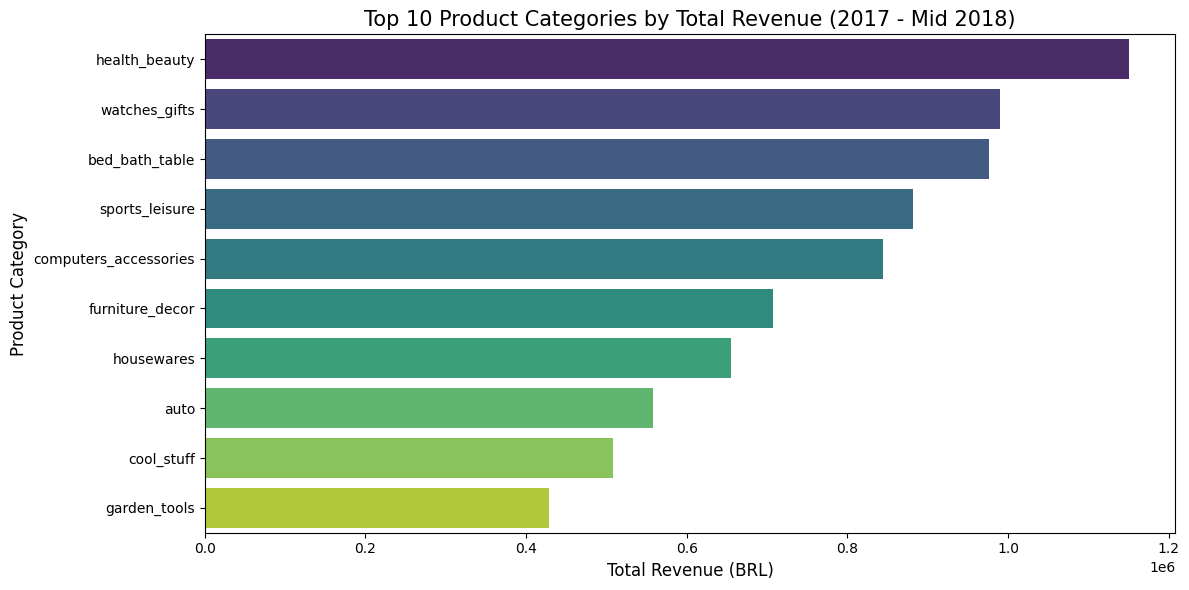

In [85]:

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_categories_revenue.values, y=top_10_categories_revenue.index, palette='viridis')
plt.title('Top 10 Product Categories by Total Revenue (2017 - Mid 2018)', fontsize=15)
plt.xlabel('Total Revenue (BRL)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()

### Pertanyaan 2: produk dan kategori produk apa yang paling sering dibeli di Sao Paulo pada periode 2017-2018?


/tmp/ipykernel_9759/2324327377.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_categories_sao_paulo.values, y=top_10_categories_sao_paulo.index, palette='viridis', ax=ax[0])
/tmp/ipykernel_9759/2324327377.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_products_sao_paulo.values, y=top_10_products_sao_paulo.index, palette='magma', ax=ax[1])


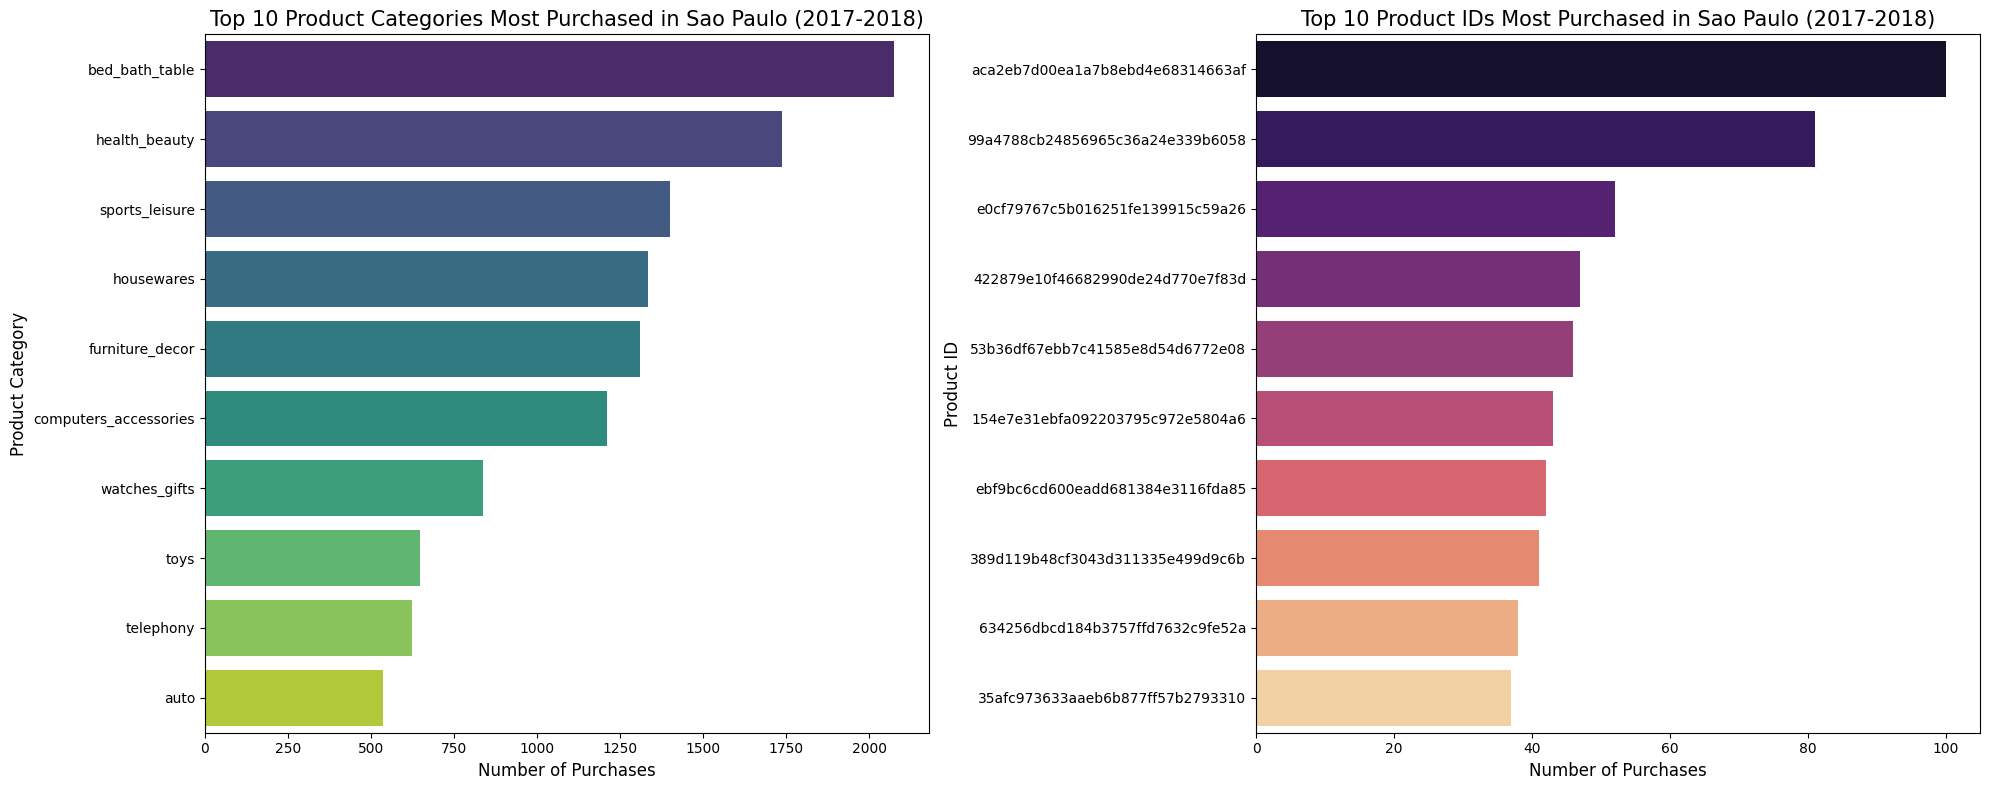

In [86]:
# Visualisasi Pertanyaan 2: Produk dan Kategori Produk Paling Sering Dibeli di Sao Paulo

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

# Plot Top 10 Product Categories
sns.barplot(x=top_10_categories_sao_paulo.values, y=top_10_categories_sao_paulo.index, palette='viridis', ax=ax[0])
ax[0].set_title('Top 10 Product Categories Most Purchased in Sao Paulo (2017-2018)', fontsize=15)
ax[0].set_xlabel('Number of Purchases', fontsize=12)
ax[0].set_ylabel('Product Category', fontsize=12)

# Plot Top 10 Product IDs
sns.barplot(x=top_10_products_sao_paulo.values, y=top_10_products_sao_paulo.index, palette='magma', ax=ax[1])
ax[1].set_title('Top 10 Product IDs Most Purchased in Sao Paulo (2017-2018)', fontsize=15)
ax[1].set_xlabel('Number of Purchases', fontsize=12)
ax[1].set_ylabel('Product ID', fontsize=12)

plt.tight_layout()
plt.show()

**Pertanyaan 3: Bagaimana tren bulanan volume transaksi dari januari 2017 hingga agustus 2018 dan wilayah mana yang memberikan kontribusi pendapatan lebih dari setengah terhadap total ppenjualan?**

/tmp/ipykernel_9759/2361078619.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sales_contribution_percentage', y='customer_state', data=regional_analysis_sorted, palette='coolwarm', ax=ax[1])


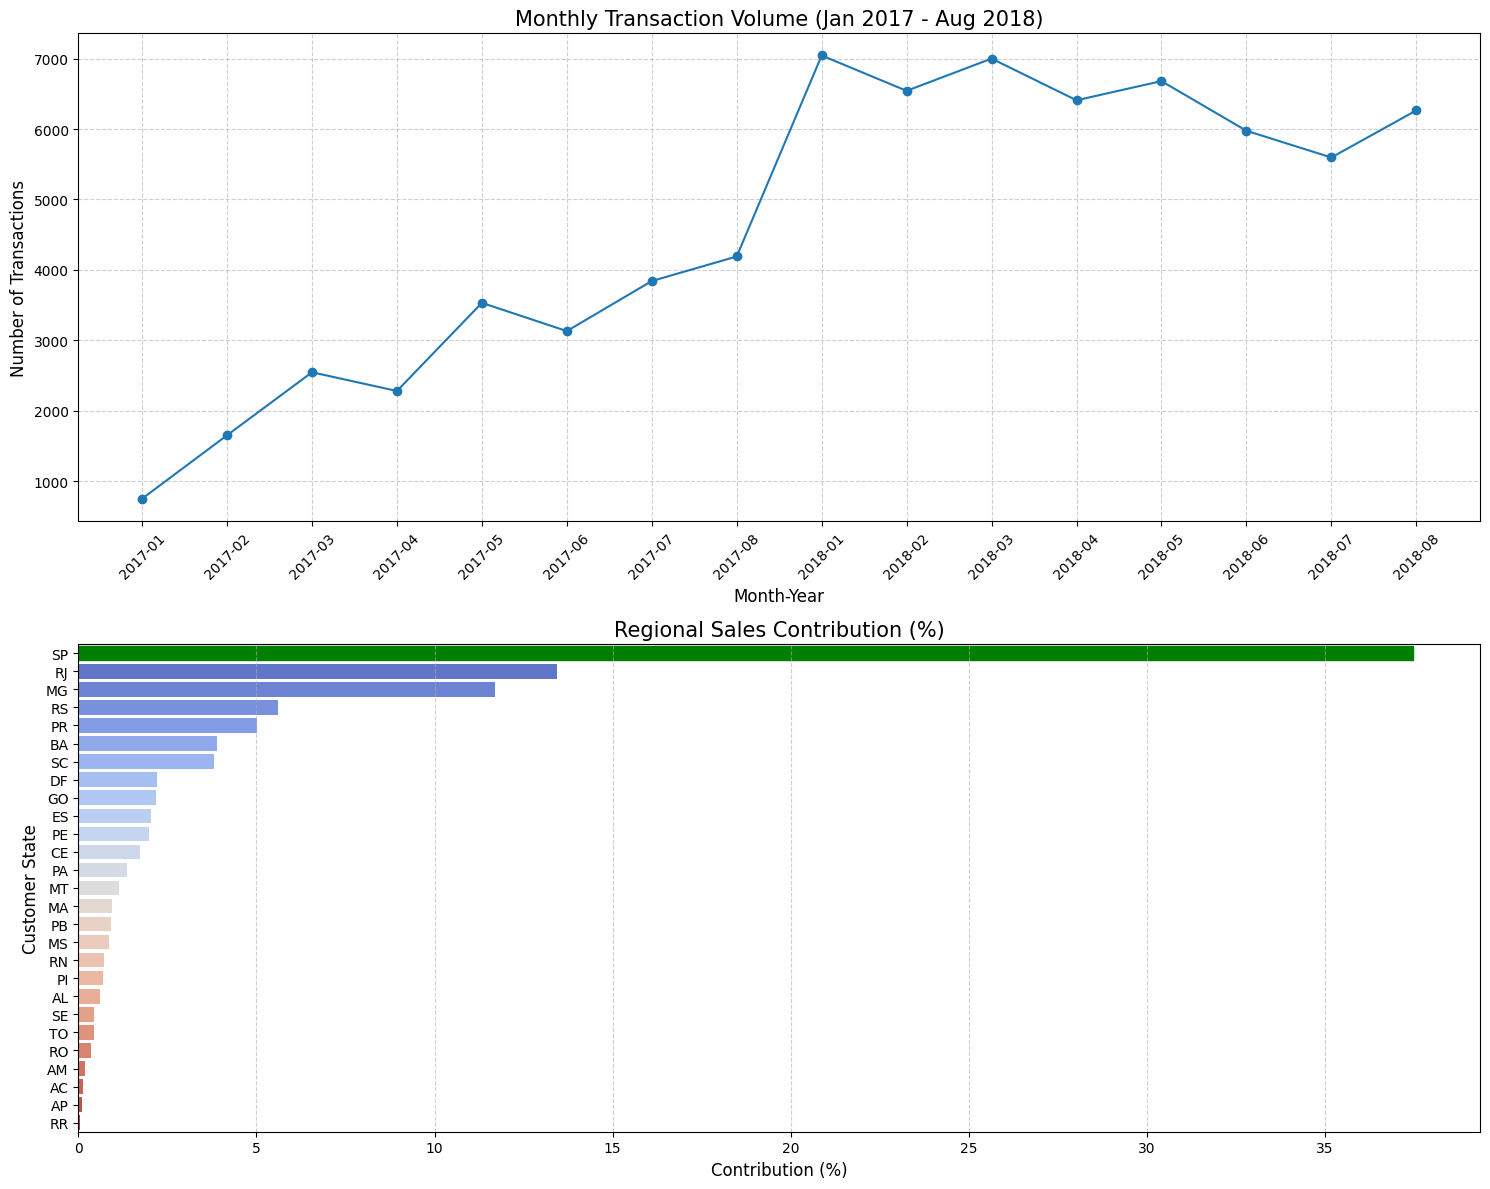

In [87]:
# Visualisasi Pertanyaan 3: Tren Bulanan dan Kontribusi Regional

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 12))

# Plot 1: Monthly Transaction Volume Trend
ax[0].plot(monthly_transactions['purchase_month_year'], monthly_transactions['order_id'], marker='o', linestyle='-')
ax[0].set_title('Monthly Transaction Volume (Jan 2017 - Aug 2018)', fontsize=15)
ax[0].set_xlabel('Month-Year', fontsize=12)
ax[0].set_ylabel('Number of Transactions', fontsize=12)
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Regional Revenue Contribution
# Ensure 'regional_analysis' is defined or re-calculate if needed
# In this case, it was defined at the end of the previous EDA cell, so it should be available.

# Sort by sales_contribution_percentage for consistent visualization
regional_analysis_sorted = regional_analysis.sort_values(by='sales_contribution_percentage', ascending=False)

sns.barplot(x='sales_contribution_percentage', y='customer_state', data=regional_analysis_sorted, palette='coolwarm', ax=ax[1])

# Highlight regions that contribute to more than 50% (cumulative)
cumulative_sum_50_percent = 0
for idx, row in regional_analysis_sorted.iterrows():
    cumulative_sum_50_percent += row['sales_contribution_percentage']
    if cumulative_sum_50_percent <= 50.0:
        ax[1].get_children()[regional_analysis_sorted.index.get_loc(idx)].set_color('green') # Highlight in green
    else:
        break # Stop highlighting once 50% is crossed

ax[1].set_title('Regional Sales Contribution (%)', fontsize=15)
ax[1].set_xlabel('Contribution (%)', fontsize=12)
ax[1].set_ylabel('Customer State', fontsize=12)
ax[1].grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Insight:**
- Kategori Health & Beauty dan Watches & Gifts adalah mesin pencetak uang (Revenue Leader). Sementara itu, Bed Bath Table memimpin dalam jumlah unit terjual (Volume Leader).
Strategi Actionable: Jangan hanya stok barang yang cepat laku (volume), tetapi berikan ruang promosi lebih besar untuk kategori kecantikan dan jam tangan karena setiap satu unit yang terjual memberikan margin kontribusi yang jauh lebih besar terhadap total pendapatan.
- Hanya dua wilayah, Sao Paulo (SP) dan Rio de Janeiro (RJ), yang menyumbang lebih dari 50% total pendapatan.
- Rekomendasi:

Optimasi Logistik: Berikan subsidi ongkos kirim atau pengiriman satu hari sampai khusus untuk wilayah SP dan RJ untuk menjaga dominasi pasar.

Up-selling: Pada saat pelanggan membeli produk Bed Bath Table (volume tinggi), tawarkan rekomendasi produk dari kategori Health & Beauty (revenue tinggi) untuk meningkatkan nilai rata-rata keranjang belanja.

Re-aktivasi: Targetkan pelanggan dengan nilai Recency > 200 hari dengan kupon diskon untuk menghidupkan kembali database pelanggan yang pasif.

## Analisis Lanjutan (Opsional)

RFM (Recency, Frequency, Monetary) Analysis:
- Recency: Kapan terakhir kali pelanggan melakukan transaksi?
- Frequency: Seberapa sering pelanggan berbelanja?
- Monetary: Berapa banyak uang yang dihabiskan pelanggan?


RFM Analysis Table (Top 5 Customers):


,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,537,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89


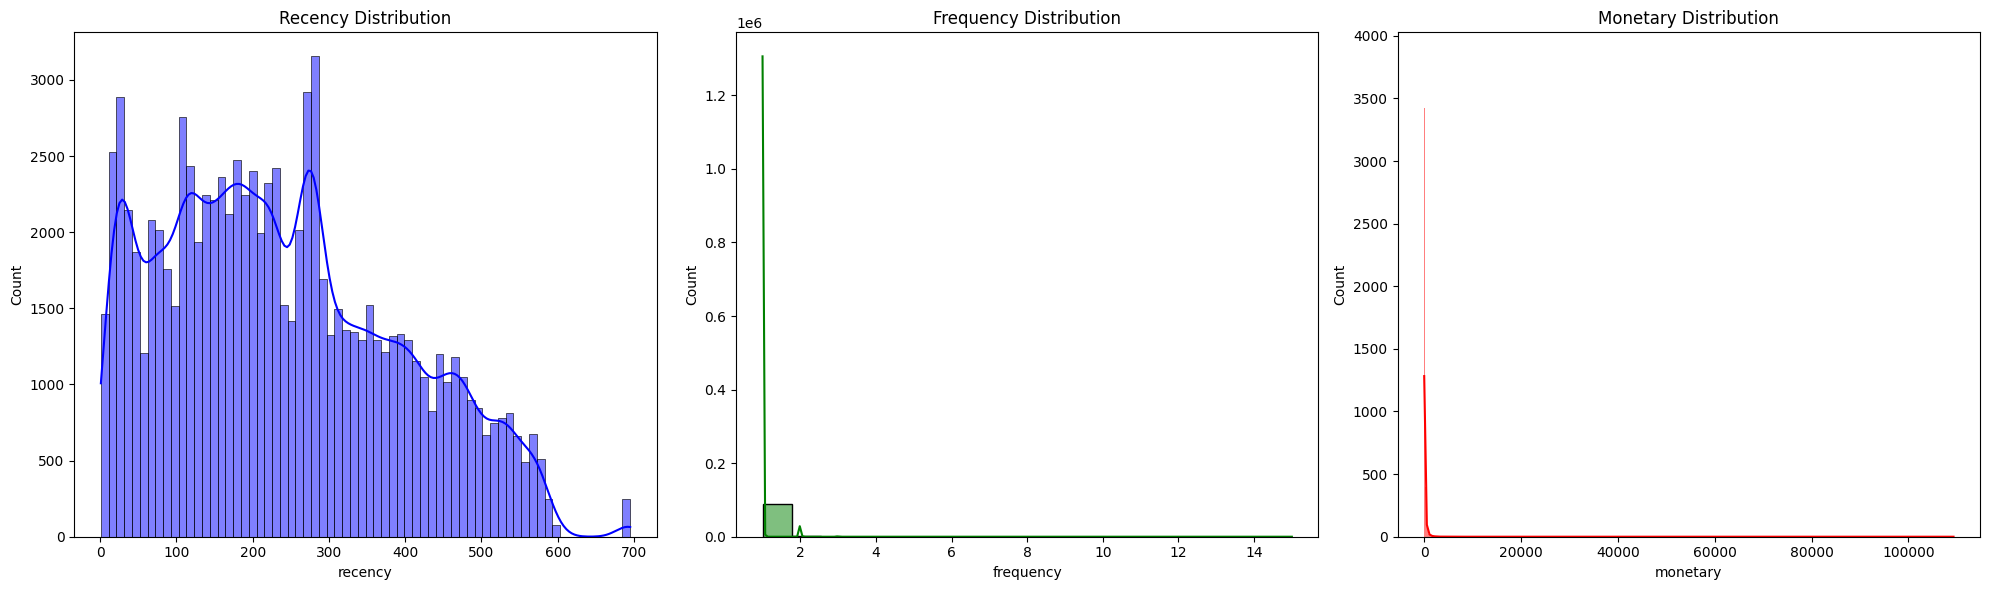

In [88]:
# Analisis Lanjutan: RFM Analysis

# Menghitung tanggal transaksi terakhir (Recency)
# Kita asumsikan 'hari ini' adalah satu hari setelah tanggal transaksi terakhir di dataset
recent_date = df_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = df_clean.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days,  # Recency
    'order_id': 'nunique',                                             # Frequency
    'payment_value': 'sum'                                             # Monetary
})

rfm_df.rename(columns={
    'order_purchase_timestamp': 'recency',
    'order_id': 'frequency',
    'payment_value': 'monetary'
}, inplace=True)

print("RFM Analysis Table (Top 5 Customers):")
display(rfm_df.head())

# Distribusi RFM
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

sns.histplot(rfm_df['recency'], kde=True, ax=ax[0], color='blue')
ax[0].set_title('Recency Distribution')

sns.histplot(rfm_df['frequency'], kde=True, ax=ax[1], color='green')
ax[1].set_title('Frequency Distribution')

sns.histplot(rfm_df['monetary'], kde=True, ax=ax[2], color='red')
ax[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

## Conclusion

**Kesimpulan Analisis**
Pertanyaan 1: Produk dan kategori produk apa yang menghasilkan total pendapatan tertinggi selama tahun 2017 hingga pertengahan 2018?

- jawaban: berdasarkan hasil analisis, kategori ppproguk dengan pendapatan tertinggi adalah Health and Beauty atau produk kesehatan dan kecantikan dengan total R$ 1,15 juta, disusul dengan kategori Watches dan Gift.

Pertanyaan 2: Produk dan kategori produk apa yang paling sering dibeli di Sao Paulo pada periode 2017-2018?

- jawaban: di wilayah Sao Paulo, kategori roduk yang paling mendominasi dari sisi volume penjualan adalah Bed Bath Table, diikuti oleh Health and Beauty. ini menunjukkan konsumen lebih mengedepankan prouduk kesehatan dan kecantikan terutama di pusat ekonomi

Pertanyaan 3: Bagaimana tren bulanan volume transaksi dari Januari 2017 hingga Agustus 2018 dan wilayah mana yang memberikan kontribusi pendapatan lebih dari setengah terhadap total penjualan?

- Jawaban: Tren transaksi mengindikasikan pertumbuhan yang pesar sejak awal 2017, dengan pundak volume terjadi ppada sekitar bulan Mei dan November. dari sisi geografis, kontribusi pendapatan sangat terpusat, praktis hanya dua negara bagian yakni Sao Paulo dan Rio de Janeiro, sudah menyumbang lebih dari setengah (50,9%) dari total pendapatan seluruh perusahaan

**Rekomendasi**

- Fokuskan ketersediaan stok produk kategori Health and Beauty di gudang sekitar Sao Paulo untuk mempercepat pengiriman

- Tingkatkan anggaran iklan atau sumber daya manusia yang terlibat dalan produk Health and Beautyy karena kategori ini memberikan profit terbesar